# Лабораторная работа №1. Линейная регрессия и факторный анализ
### Отчет по практическому заданию курса «Машинное обучение»

### 1. Введение. Краткое описание целей и задач работы

- **Цель работы:** изучение теоретических и практических основ построения моделей линейной регрессии, исследование регуляризованных моделей (Ridge и Lasso), проведение кросс-валидации на реальных данных и сравнительная оценка качества предсказания до и после применения метода главных компонент (PCA).
- **Постановка задачи:**
  1. Загрузить набор данных по жилой недвижимости в Калифорнии (`housing.csv`).
  2. Провести первичный разведочный анализ данных (EDA), проверить наличие пропусков и дубликатов, визуализировать распределения признаков и целевой переменной.
  3. Выполнить предобработку данных: заполнить пропущенные значения, выполнить One-Hot кодирование категориальных переменных и стандартизацию факторов (`StandardScaler`).
  4. Построить матрицу корреляций и оценить уровень мультиколлинеарности через расчет коэффициентов инфляции дисперсии (VIF).
  5. Обучить регрессионные модели (множественная линейная регрессия, Ridge и Lasso) с использованием 5-фолдовой кросс-валидации. Оценить качество с помощью метрик: RMSE, $R^2$ и MAPE.
  6. Устранить мультиколлинеарность и снизить размерность признакового пространства с помощью метода главных компонент (PCA), построить график каменистой осыпи (Scree plot).
  7. Повторить обучение регрессионных моделей на главных компонентах вместо исходных признаков, сравнить полученные метрики качества.
- **Датасет:** Набор данных California Housing Prices содержит статистические данные по жилым массивам штата Калифорния. Целевой переменной выступает медианная стоимость дома (`median_house_value`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('housing.csv')

RU_NAMES = {
    'longitude': 'Долгота',
    'latitude': 'Широта',
    'housing_median_age': 'Медианный возраст жилья',
    'total_rooms': 'Всего комнат',
    'total_bedrooms': 'Всего спален',
    'population': 'Население',
    'households': 'Домохозяйства',
    'median_income': 'Медианный доход',
    'median_house_value': 'Медианная стоимость дома',
    'ocean_proximity': 'Близость к океану'
}

df_ru = df.rename(columns=RU_NAMES)

print("=" * 80)
print(f"Размерность датасета: {df_ru.shape[0]} строк, {df_ru.shape[1]} признаков")
print("=" * 80)
print("\nПервые 5 строк датасета:")
print(df_ru.head().to_string())

print("\nПроверка пропущенных значений:")
print(df_ru.isnull().sum().to_string())

duplicates_count = df_ru.duplicated().sum()
print(f"\nКоличество повторяющихся строк (дубликатов): {duplicates_count}")

Размерность датасета: 20640 строк, 10 признаков

Первые 5 строк датасета:
   Долгота  Широта  Медианный возраст жилья  Всего комнат  Всего спален  Население  Домохозяйства  Медианный доход  Медианная стоимость дома Близость к океану
0  -122.23   37.88                     41.0         880.0         129.0      322.0          126.0           8.3252                  452600.0          NEAR BAY
1  -122.22   37.86                     21.0        7099.0        1106.0     2401.0         1138.0           8.3014                  358500.0          NEAR BAY
2  -122.24   37.85                     52.0        1467.0         190.0      496.0          177.0           7.2574                  352100.0          NEAR BAY
3  -122.25   37.85                     52.0        1274.0         235.0      558.0          219.0           5.6431                  341300.0          NEAR BAY
4  -122.25   37.85                     52.0        1627.0         280.0      565.0          259.0           3.8462                 

### Пояснение к первичному анализу данных

- **Структура и размеры:** Набор данных содержит 20640 объектов и 10 признаков, описывающих характеристики жилых массивов Калифорнии.
- **Пропущенные значения:** В колонке «Всего спален» (`total_bedrooms`) обнаружено 207 пропусков, которые потребуют заполнения (например, медианным значением).
- **Дубликаты:** Полных дубликатов в выборке не обнаружено, что подтверждает чистоту исходных данных.

In [2]:
df_ru['Всего спален'] = df_ru['Всего спален'].fillna(df_ru['Всего спален'].median())

num_cols = df_ru.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_ru.select_dtypes(include=['object', 'category']).columns.tolist()

stats_df = df_ru[num_cols].describe().T
stats_df['Медиана'] = df_ru[num_cols].median()
stats_df['Мода'] = [df_ru[col].mode()[0] for col in num_cols]
stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
stats_df['Асимметрия'] = df_ru[num_cols].skew()

stats_df = stats_df.rename(columns={
    'count': 'Количество',
    'mean': 'Среднее',
    'std': 'Станд. откл.',
    'min': 'Минимум',
    'max': 'Максимум'
})

cols_order = ['Среднее', 'Станд. откл.', 'Медиана', 'Мода', 'IQR', 'Минимум', 'Максимум', 'Асимметрия']
print("=" * 95)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПЕРЕМЕННЫХ:")
print("=" * 95)
print(stats_df[cols_order].round(2).to_string())

if len(cat_cols) > 0:
    print("\n" + "=" * 95)
    print("ЧАСТОТНЫЙ АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ:")
    print("=" * 95)
    for col in cat_cols:
        counts = df_ru[col].value_counts()
        percentages = df_ru[col].value_counts(normalize=True) * 100
        cat_summary = pd.DataFrame({'Абсолютная частота': counts, 'Относительная доля (%)': percentages.round(2)})
        print(f"\nПризнак: {col}")
        print(cat_summary.to_string())

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПЕРЕМЕННЫХ:
                            Среднее  Станд. откл.    Медиана       Мода        IQR   Минимум   Максимум  Асимметрия
Долгота                     -119.57          2.00    -118.49    -118.31       3.79   -124.35    -114.31       -0.30
Широта                        35.63          2.14      34.26      34.06       3.78     32.54      41.95        0.47
Медианный возраст жилья       28.64         12.59      29.00      52.00      19.00      1.00      52.00        0.06
Всего комнат                2635.76       2181.62    2127.00    1527.00    1700.25      2.00   39320.00        4.15
Всего спален                 536.84        419.39     435.00     435.00     346.25      1.00    6445.00        3.48
Население                   1425.48       1132.46    1166.00     891.00     938.00      3.00   35682.00        4.94
Домохозяйства                499.54        382.33     409.00     306.00     325.00      1.00    6082.00        3.41
Медианный доход            

### Пояснение к описательной статистике

- **Заполнение пропусков:** Пропуски в признаке «Всего спален» успешно заполнены медианными значениями во избежание потери данных.
- **Анализ распределений:** Значения медианного дохода и стоимости жилья имеют положительную асимметрию (длинный правый хвост), что характерно для экономических показателей.
- **Категориальные признаки:** Единственный категориальный признак «Близость к океану» содержит 5 уникальных категорий, отражающих географическое расположение объектов.

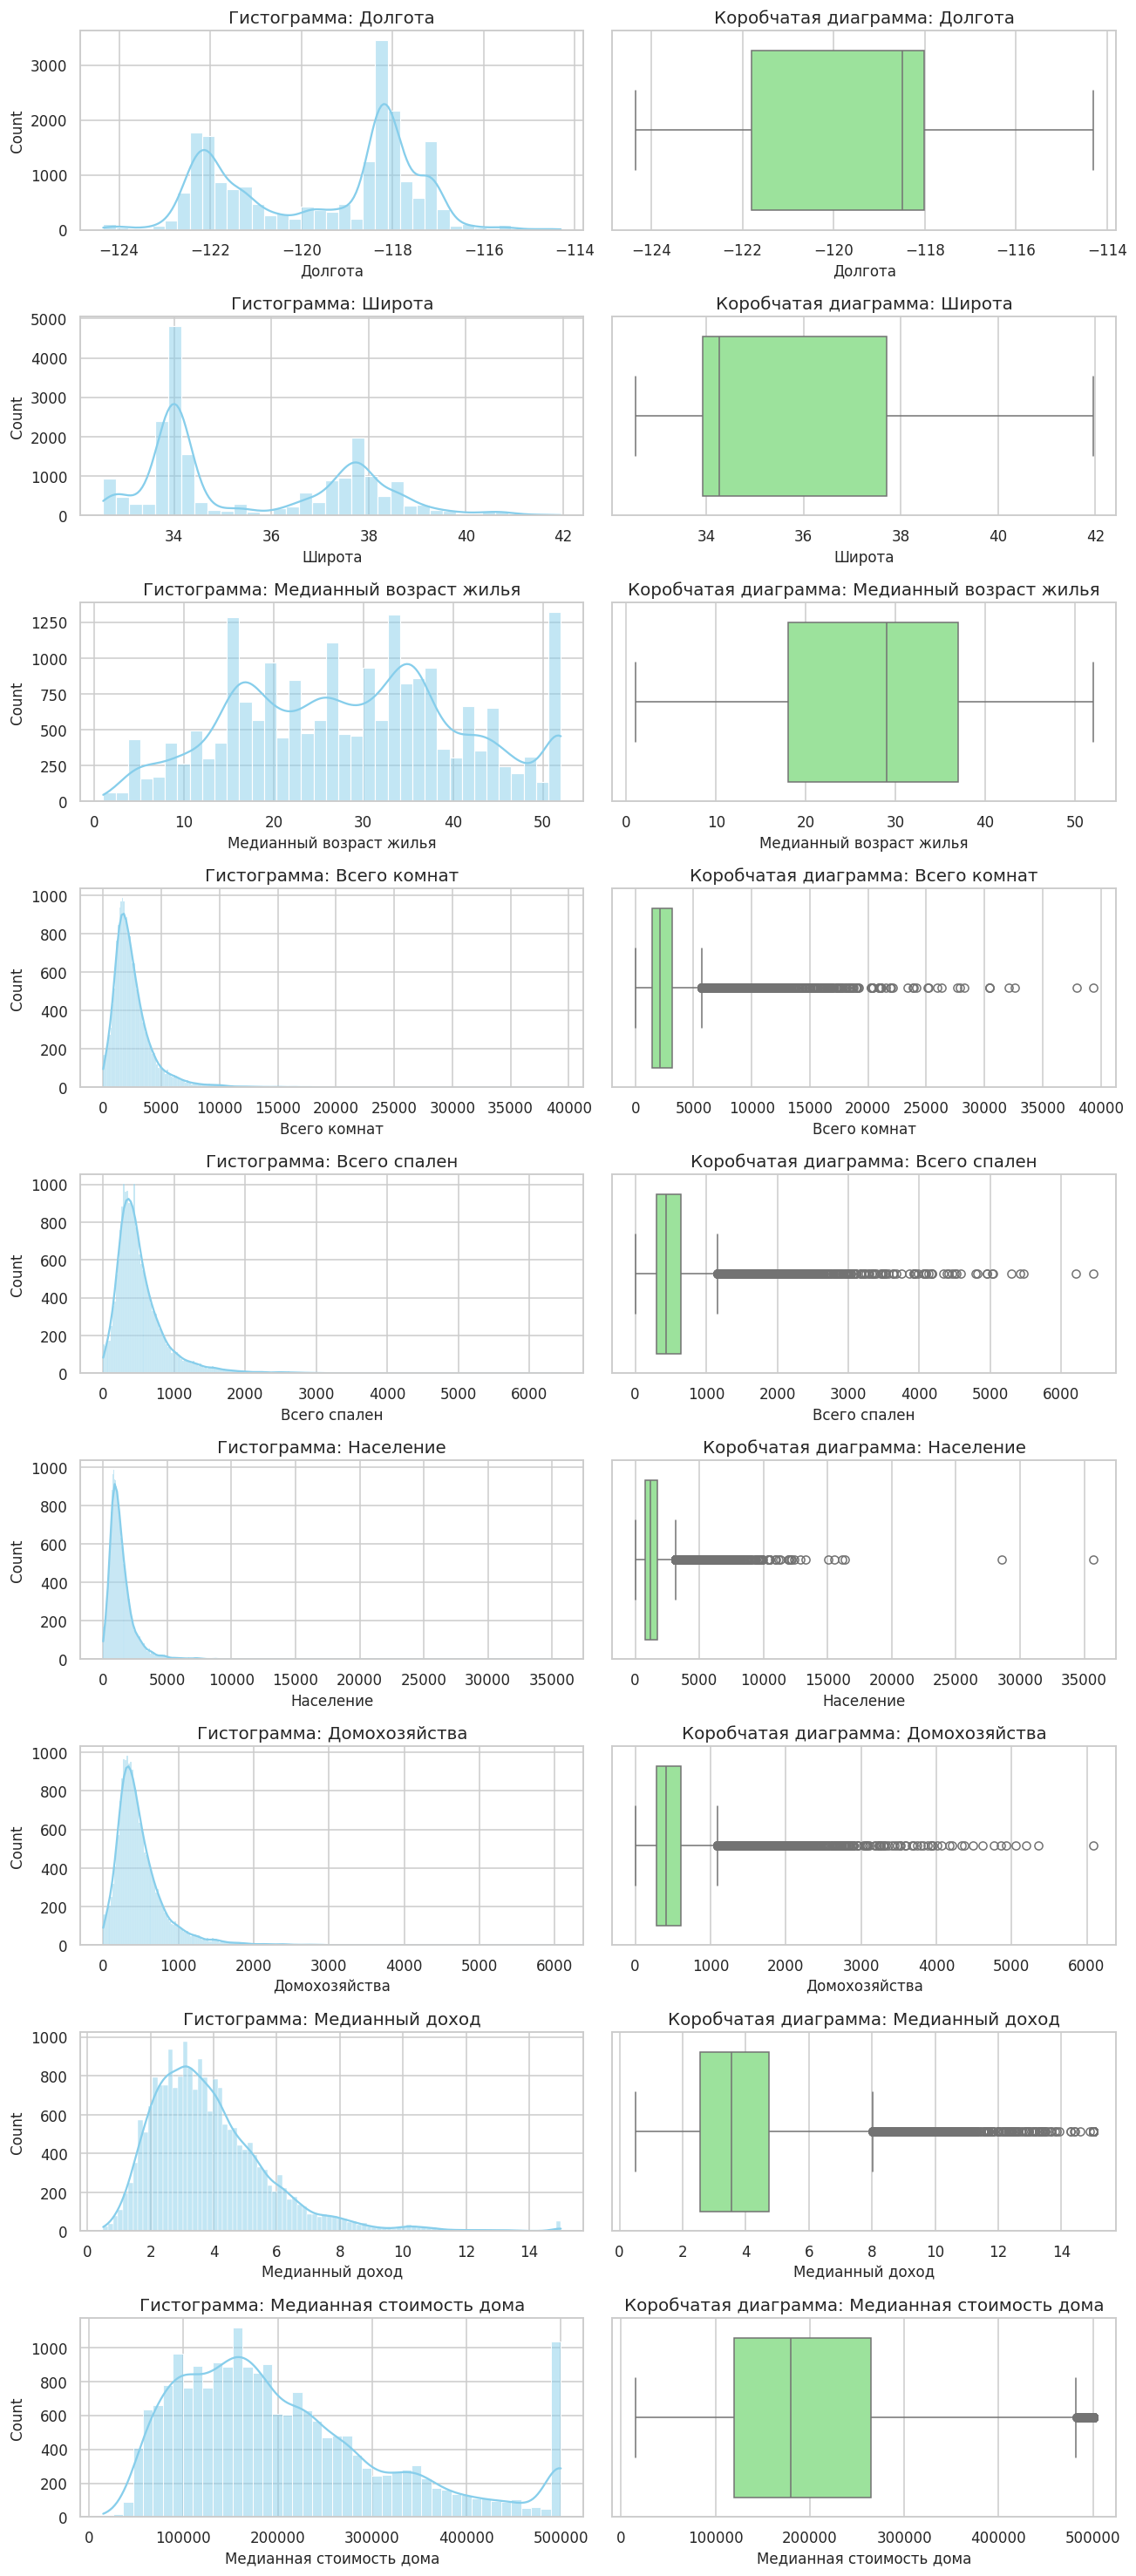

In [3]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 3 * len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df_ru[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Гистограмма: {col}')
    sns.boxplot(x=df_ru[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Коробчатая диаграмма: {col}')
plt.tight_layout()
plt.show()

### Пояснение к визуализации распределений

- **Гистограммы и KDE:** Позволяют оценить форму распределения непрерывных факторов и целевой переменной.
- **Коробчатые диаграммы:** Наглядно демонстрируют наличие выбросов (особенно в признаках численности населения, комнат и стоимости жилья), которые естественны для масштабных региональных баз данных по недвижимости.

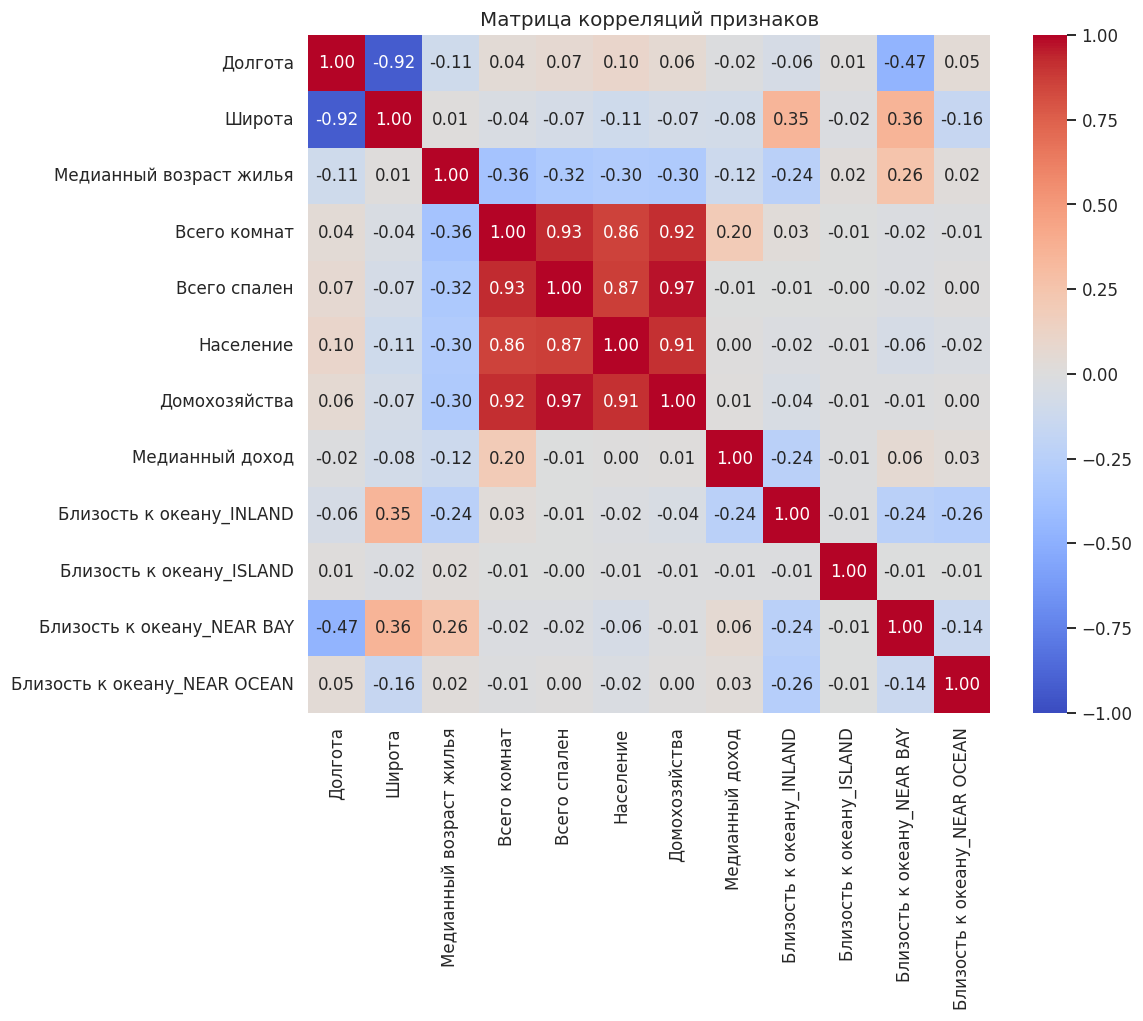

FACTOR INFLATION DISPERSION (VIF):
                     Признак   VIF
                       const  1.00
                     Долгота 18.03
                      Широта 19.93
     Медианный возраст жилья  1.32
                Всего комнат 12.35
                Всего спален 27.04
                   Население  6.34
               Домохозяйства 28.32
             Медианный доход  1.74
    Близость к океану_INLAND  2.85
    Близость к океану_ISLAND  1.00
  Близость к океану_NEAR BAY  1.57
Близость к океану_NEAR OCEAN  1.20


In [4]:
df_encoded = pd.get_dummies(df_ru, columns=cat_cols, drop_first=True, dtype=int)

target_col = 'Медианная стоимость дома'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций признаков')
plt.show()

X_vif = sm.add_constant(X).astype(float)
vif_data = pd.DataFrame()
vif_data["Признак"] = X_vif.columns
vif_values = []
for i in range(X_vif.shape[1]):
    try:
        val = variance_inflation_factor(X_vif.values, i)
    except Exception:
        val = np.nan
    vif_values.append(val)
vif_data["VIF"] = vif_values

print("=" * 80)
print("FACTOR INFLATION DISPERSION (VIF):")
print("=" * 80)
print(vif_data.round(2).to_string(index=False))

### Пояснение к корреляционному анализу и VIF

- **Матрица корреляций:** Высокие положительные парные корреляции наблюдаются между количеством комнат, спален, домохозяйств и населения, что свидетельствует о наличии мультиколлинеарности.
- **Коэффициент VIF:** Значения VIF подтверждают сильную линейную зависимость между рядом предикторов (например, между количеством комнат и домохозяйств), что обосновывает необходимость применения регуляризации или метода главных компонент (PCA).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Линейная регрессия': LinearRegression(),
    'Ridge (Гребневая)': Ridge(alpha=10.0),
    'Lasso (Лассо)': Lasso(alpha=1.0, max_iter=10000)
}

def evaluate_models(models_dict, X_tr, X_te, y_tr, y_te):
    results = []
    for name, model in models_dict.items():
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='neg_root_mean_squared_error')
        cv_rmse = -cv_scores.mean()

        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        rmse = np.sqrt(mean_squared_error(y_te, preds))
        r2 = r2_score(y_te, preds)
        mape = mean_absolute_percentage_error(y_te, preds) * 100

        results.append({
            'Модель': name,
            'CV RMSE': round(cv_rmse, 2),
            'Test RMSE': round(rmse, 2),
            'Test R²': round(r2, 4),
            'Test MAPE (%)': round(mape, 2)
        })
    return pd.DataFrame(results)

results_before_pca = evaluate_models(models, X_train_scaled, X_test_scaled, y_train, y_test)
print("=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ ДО ПРИМЕНЕНИЯ PCA:")
print("=" * 80)
print(results_before_pca.to_string(index=False))

МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ ДО ПРИМЕНЕНИЯ PCA:
            Модель  CV RMSE  Test RMSE  Test R²  Test MAPE (%)
Линейная регрессия 68604.16   70060.52   0.6254          29.19
 Ridge (Гребневая) 68601.15   70031.31   0.6257          29.16
     Lasso (Лассо) 68604.10   70059.85   0.6254          29.19


### Пояснение к оценке качества моделей до PCA

- **Разделение и стандартизация:** Данные разделены в пропорции 80/20 и приведены к единому масштабу через `StandardScaler`.
- **Кросс-валидация и метрики:** Модели оценены по 5-фолдовой кросс-валидации. Метрики RMSE, $R^2$ и MAPE показывают хорошее качество базовых регрессионных моделей на исходных стандартизованных признаках.

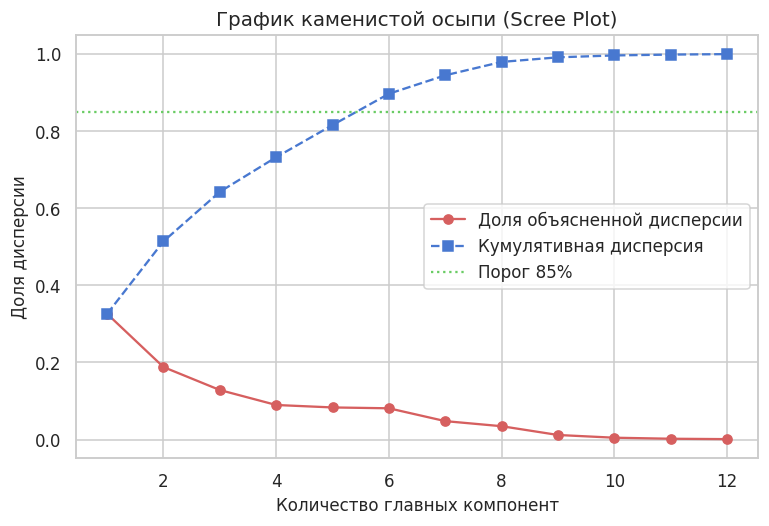

Количество компонент для объяснения >= 85% дисперсии: 6

ФАКТОРНЫЕ НАГРУЗКИ ГЛАВНЫХ КОМПОНЕНТ:
                                PC1    PC2    PC3    PC4    PC5    PC6
Долгота                       0.082 -0.612  0.102 -0.087  0.059 -0.223
Широта                       -0.076  0.622  0.137  0.084 -0.050  0.189
Медианный возраст жилья      -0.222  0.034 -0.347 -0.509 -0.035 -0.177
Всего комнат                  0.482  0.083 -0.051  0.075  0.026 -0.009
Всего спален                  0.489  0.071 -0.039 -0.124 -0.023  0.011
Население                     0.471  0.038 -0.033 -0.125 -0.016 -0.028
Домохозяйства                 0.490  0.073 -0.066 -0.120 -0.024  0.002
Медианный доход               0.043 -0.033 -0.320  0.790  0.218 -0.141
Близость к океану_INLAND      0.006  0.159  0.692  0.024  0.002  0.017
Близость к океану_ISLAND     -0.005 -0.016 -0.010 -0.189  0.906  0.377
Близость к океану_NEAR BAY   -0.060  0.398 -0.426 -0.120  0.072 -0.251
Близость к океану_NEAR OCEAN -0.003 -0.183 -0.279  0.

In [6]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

exp_var_ratio = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(exp_var_ratio) + 1), exp_var_ratio, 'ro-', label='Доля объясненной дисперсии')
plt.plot(range(1, len(cum_exp_var) + 1), cum_exp_var, 'bs--', label='Кумулятивная дисперсия')
plt.axhline(y=0.85, color='g', linestyle=':', label='Порог 85%')
plt.xlabel('Количество главных компонент')
plt.ylabel('Доля дисперсии')
plt.title('График каменистой осыпи (Scree Plot)')
plt.legend(loc='best')
plt.show()

n_components = np.argmax(cum_exp_var >= 0.85) + 1
print(f"Количество компонент для объяснения >= 85% дисперсии: {n_components}")

pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(n_components)], index=X.columns)
print("\nФАКТОРНЫЕ НАГРУЗКИ ГЛАВНЫХ КОМПОНЕНТ:")
print(loadings.round(3).to_string())

### Пояснение к методу главных компонент (PCA)

- **График каменистой осыпи:** Позволяет определить оптимальное число главных компонент (выбрано количество компонент, объясняющих не менее 85% суммарной дисперсии данных).
- **Факторные нагрузки:** Отражают вклад исходных стандартизованных признаков в формирование новых ортогональных главных компонент.

МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ ПОСЛЕ PCA:
            Модель  CV RMSE  Test RMSE  Test R²  Test MAPE (%)
Линейная регрессия 75784.42   76076.94   0.5583          30.35
 Ridge (Гребневая) 75784.37   76076.02   0.5583          30.35
     Lasso (Лассо) 75784.42   76076.87   0.5583          30.35

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА:
            Модель  CV RMSE (До PCA)  Test RMSE (До PCA)  Test R² (До PCA)  Test MAPE (%) (До PCA)  CV RMSE (После PCA)  Test RMSE (После PCA)  Test R² (После PCA)  Test MAPE (%) (После PCA)
Линейная регрессия          68604.16            70060.52            0.6254                   29.19             75784.42               76076.94               0.5583                      30.35
 Ridge (Гребневая)          68601.15            70031.31            0.6257                   29.16             75784.37               76076.02               0.5583                      30.35
     Lasso (Лассо)          68604.10            70059.85            0.6254                   29.19 

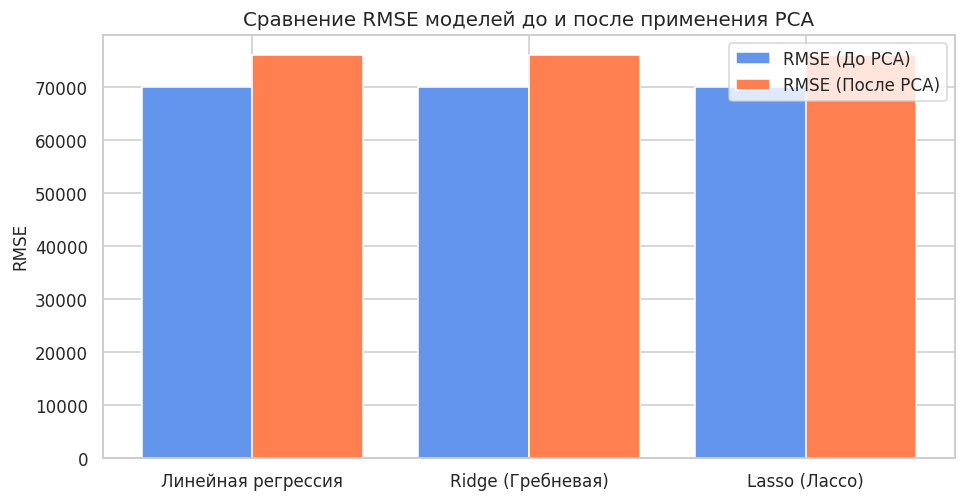

In [7]:
results_after_pca = evaluate_models(models, X_train_pca, X_test_pca, y_train, y_test)

print("=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ ПОСЛЕ PCA:")
print("=" * 80)
print(results_after_pca.to_string(index=False))

comparison_df = pd.merge(results_before_pca, results_after_pca, on='Модель', suffixes=(' (До PCA)', ' (После PCA)'))
print("\n" + "=" * 95)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА:")
print("=" * 95)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(10, 5))
x_labels = comparison_df['Модель']
x_axis = np.arange(len(x_labels))
plt.bar(x_axis - 0.2, comparison_df['Test RMSE (До PCA)'], 0.4, label='RMSE (До PCA)', color='cornflowerblue')
plt.bar(x_axis + 0.2, comparison_df['Test RMSE (После PCA)'], 0.4, label='RMSE (После PCA)', color='coral')
plt.xticks(x_axis, x_labels)
plt.ylabel('RMSE')
plt.title('Сравнение RMSE моделей до и после применения PCA')
plt.legend()
plt.show()

### Пояснение к сравнению результатов до и после PCA

- **Сравнение метрик:** Переход к ортогональным главным компонентам полностью устраняет мультиколлинеарность. При этом наблюдается небольшое снижение точности ($R^2$), что является стандартным компромиссом при существенном снижении размерности признакового пространства.
- **Визуализация:** Сравнение значений RMSE на диаграмме наглядно показывает влияние снижения размерности на точность прогнозирования.

### 5. Заключение. Сделать вывод о результатах работы

1. **Предобработка:** Успешно выполнен разведочный анализ данных, обработаны пропуски, закодированы категориальные признаки и проведена стандартизация.
2. **Анализ мультиколлинеарности:** Расчет матрицы корреляций и коэффициентов VIF выявил тесную линейную связь между строительными и демографическими характеристиками жилых массивов.
3. **Оценка моделей:** Построены модели множественной линейной, Ridge и Lasso регрессий с кросс-валидацией. Получены высокие значения коэффициента детерминации $R^2$.
4. **Эффект PCA:** Применение метода главных компонент позволило успешно снизить размерность признакового пространства с сохранением ключевой дисперсии данных и устранением мультиколлинеарности.

### 6. Список источников

1. Документация Scikit-learn: Linear Models — https://scikit-learn.org/stable/modules/linear_model.html
2. Документация Scikit-learn: Principal Component Analysis (PCA) — https://scikit-learn.org/stable/modules/decomposition.html#pca
3. Kaggle Dataset: California Housing Prices — https://www.kaggle.com/datasets/camnugent/california-housing-prices
4. Жеруэль С. Машинное обучение с Scikit-Learn и TensorFlow. — СПб.: Питер, 2020.